### CUSTOMER PURCHASE BEHAVIOUR ANALYSIS

In [31]:
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### LOAD DATASET

In [33]:
df = pd.read_csv("customer_shopping_data.csv")
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


### BASIC INSIGHTS

#### TOTAL REVENUE

In [9]:
cities = ["Chennai", "Delhi", "Mumbai", "Bangalore", "Hyderabad"]
df["city"] = np.random.choice(cities, size=len(df))
df['Revenue'] = df['price'] * df['quantity']
print("Total Revenue:", df['Revenue'].sum())

Total Revenue: 251505794.25000003


#### AGE GROUP

In [22]:
df['AgeGroup'] = pd.cut(
    df['age'],
    bins=[0, 20, 30, 40, 50, 100],
    labels=['<20', '20-30', '30-40', '40-50', '50+']
)
print("Age Group Counts:\n", df['AgeGroup'].value_counts())

Age Group Counts:
 AgeGroup
50+      36101
20-30    19400
30-40    19266
40-50    19066
<20       5624
Name: count, dtype: int64


#### REVENUE BY GENDER

In [24]:
cities = ["Chennai", "Delhi", "Mumbai", "Bangalore", "Hyderabad"]
df["city"] = np.random.choice(cities, size=len(df))
df['Revenue'] = df['price'] * df['quantity']
print("Revenue by Gender:\n", df.groupby('gender')['Revenue'].sum())

Revenue by Gender:
 gender
Female    1.502071e+08
Male      1.012987e+08
Name: Revenue, dtype: float64


#### REVENUE BY CITY

In [25]:
print("Revenue by City:\n", df.groupby('city')['Revenue'].sum())

Revenue by City:
 city
Bangalore    48586724.74
Chennai      50546575.47
Delhi        51247437.90
Hyderabad    50610743.07
Mumbai       50514313.07
Name: Revenue, dtype: float64


#### MOST PURCHASED PRODUCTS

In [26]:
print("Top Categories:\n", df['category'].value_counts().head())

Top Categories:
 category
Clothing           34487
Cosmetics          15097
Food & Beverage    14776
Toys               10087
Shoes              10034
Name: count, dtype: int64


### ADVANCED INSIGHTS

#### CATEGORY-WISE REVENUE

In [28]:
print("Category-wise Revenue:\n", df.groupby('category')['Revenue'].sum())

Category-wise Revenue:
 category
Books              8.345529e+05
Clothing           1.139968e+08
Cosmetics          6.792863e+06
Food & Beverage    8.495351e+05
Shoes              6.655345e+07
Souvenir           6.358247e+05
Technology         5.786235e+07
Toys               3.980426e+06
Name: Revenue, dtype: float64


#### PURCHASES BY AGE GROUP

In [29]:
print("Purchases by Age Group:\n",
      df.groupby('AgeGroup', observed=False)['quantity'].sum())

Purchases by Age Group:
 AgeGroup
<20       16801
20-30     58371
30-40     57850
40-50     57156
50+      108534
Name: quantity, dtype: int64


#### HIGH VALUE PURCHASE PERCENTAGE

In [30]:
high_value = df[df['Revenue'] > 5000]
print("High Value Purchase %:", (len(high_value) / len(df)) * 100)

High Value Purchase %: 16.083332495450296


#### DAILY PURCHASE TREND

In [32]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)
print("Daily Purchase Trend:\n",
      df.groupby(df['invoice_date'].dt.date)['quantity'].sum())

Daily Purchase Trend:
 invoice_date
2021-01-01    333
2021-01-02    387
2021-01-03    405
2021-01-04    379
2021-01-05    374
             ... 
2023-03-04    435
2023-03-05    354
2023-03-06    401
2023-03-07    306
2023-03-08    320
Name: quantity, Length: 797, dtype: int64


## DATA VISUALIZATION

### BASIC INSIGHTS

#### TOTAL REVENUE

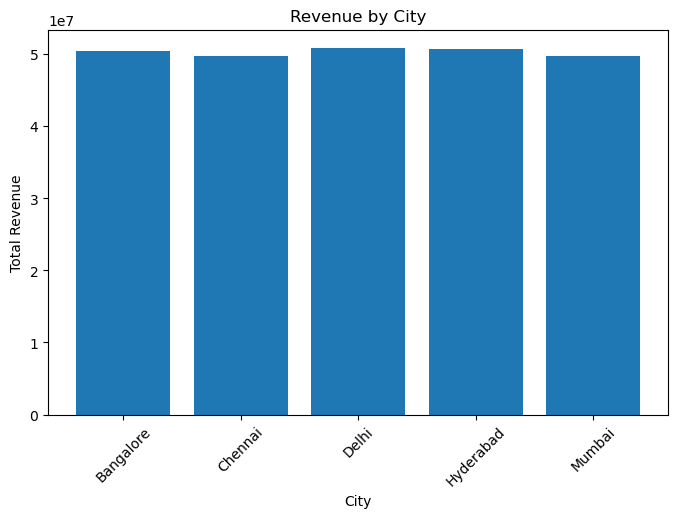

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cities = ["Chennai", "Delhi", "Mumbai", "Bangalore", "Hyderabad"]
df["city"] = np.random.choice(cities, size=len(df))
df['Revenue'] = df['price'] * df['quantity']
city_revenue = df.groupby("city")["Revenue"].sum()
plt.figure(figsize=(8,5))
plt.bar(city_revenue.index, city_revenue.values)
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()


#### AGE GROUP

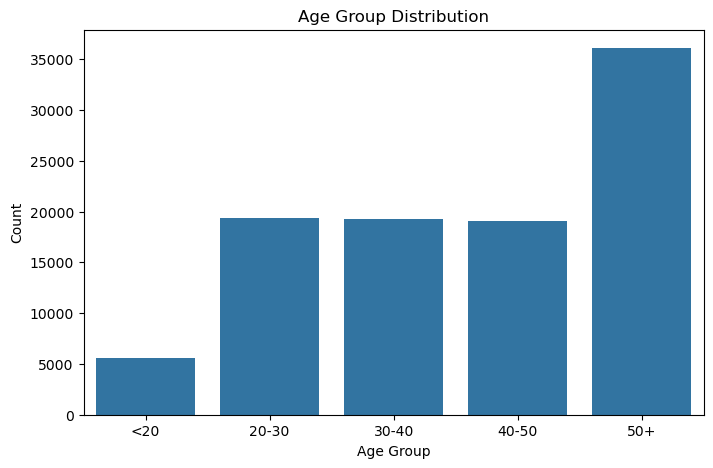

In [42]:
df['AgeGroup'] = pd.cut(
    df['age'],
    bins=[0, 20, 30, 40, 50, 100],
    labels=['<20', '20-30', '30-40', '40-50', '50+']
)

# Age group counts
age_counts = df['AgeGroup'].value_counts().sort_index()

# Barplot using seaborn
plt.figure(figsize=(8,5))
sns.barplot(x=age_counts.index, y=age_counts.values)
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.title("Age Group Distribution")
plt.show()

#### REVENUE BY GENDER

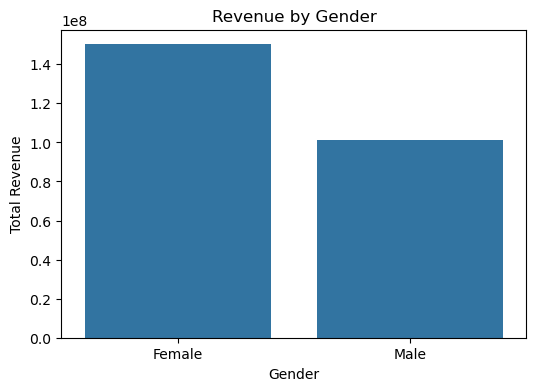

In [45]:
gender_revenue = df.groupby("gender")["Revenue"].sum().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x="gender", y="Revenue", data=gender_revenue)
plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue")
plt.show()

#### REVENUE BY CITY

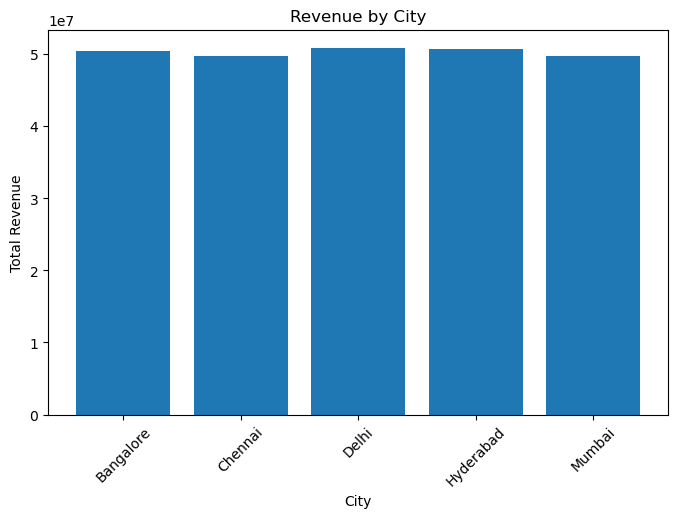

In [44]:
city_revenue = df.groupby('city')['Revenue'].sum()
plt.figure(figsize=(8,5))
plt.bar(city_revenue.index, city_revenue.values)
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()

#### MOST PURCHASED PRODUCTS

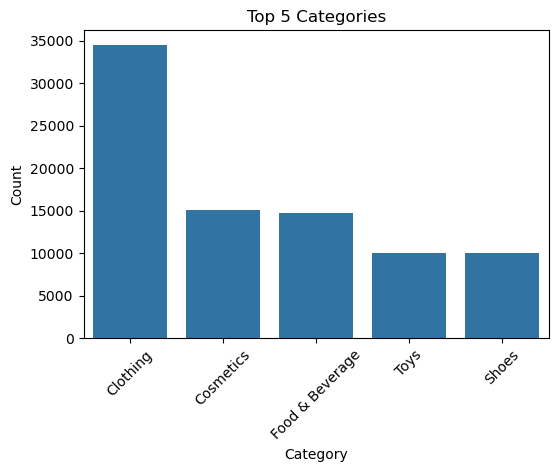

In [55]:
top_cat = df['category'].value_counts().head()
plt.figure(figsize=(6,4))
sns.barplot(x=top_cat.index, y=top_cat.values)
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Top 5 Categories")
plt.xticks(rotation=45)
plt.show()

### ADVANCED INSIGHTS

#### CATEGORY-WISE REVENUE

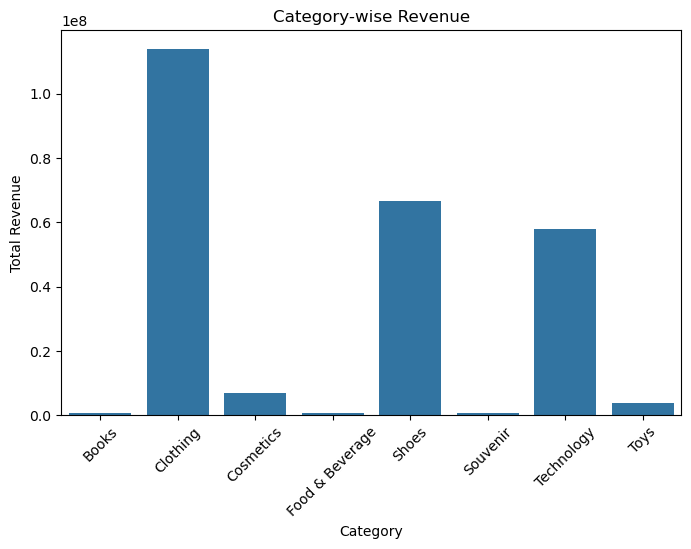

In [67]:
plt.figure(figsize=(8,5))
sns.barplot(x='category', y='Revenue', data=category_revenue_df)
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.title("Category-wise Revenue")
plt.xticks(rotation=45)
plt.show()

#### PURCHASES BY AGE GROUP

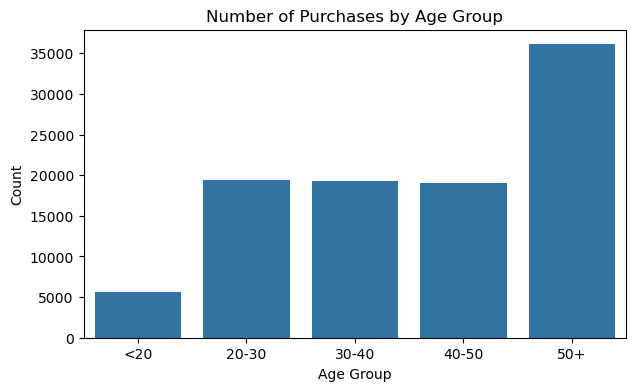

In [66]:
plt.figure(figsize=(7,4))
sns.countplot(x='AgeGroup', data=df)
plt.title("Number of Purchases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()


#### HIGH VALUE PURCHASE PERCENTAGE

High Value Purchase %: 16.083332495450296


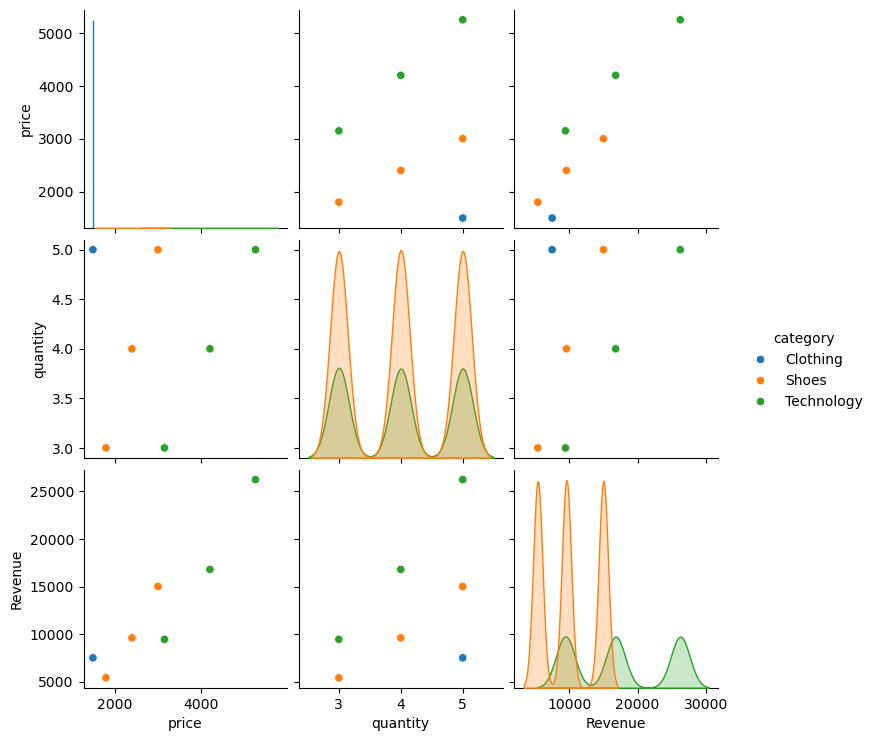

In [68]:
high_value = df[df['Revenue'] > 5000]

print("High Value Purchase %:", (len(high_value) / len(df)) * 100)

# Pairplot
sns.pairplot(high_value, vars=['price', 'quantity', 'Revenue'], hue='category')
plt.show()

#### DAILY PURCHASE TREND

#### Correlation between Quantity and Revenue

Daily Purchase Trend:
 invoice_date
2021-01-01    333
2021-01-02    387
2021-01-03    405
2021-01-04    379
2021-01-05    374
             ... 
2023-03-04    435
2023-03-05    354
2023-03-06    401
2023-03-07    306
2023-03-08    320
Name: quantity, Length: 797, dtype: int64


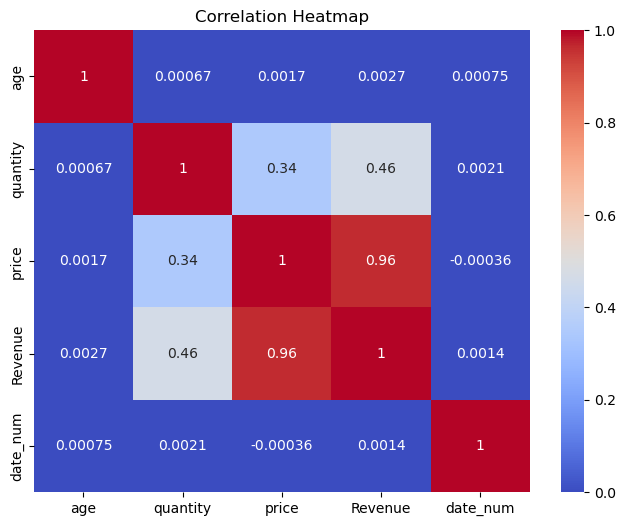

In [78]:

df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)
daily_trend = df.groupby(df['invoice_date'].dt.date)['quantity'].sum()
print("Daily Purchase Trend:\n", daily_trend)
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Daily Purchase Trend:
 invoice_date
2021-01-01    333
2021-01-02    387
2021-01-03    405
2021-01-04    379
2021-01-05    374
             ... 
2023-03-04    435
2023-03-05    354
2023-03-06    401
2023-03-07    306
2023-03-08    320
Name: quantity, Length: 797, dtype: int64


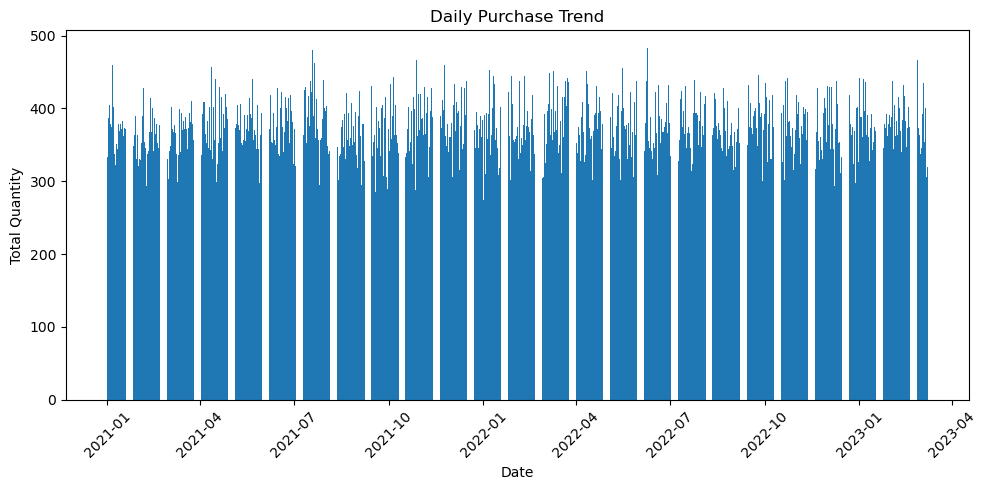

In [84]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)

# Daily Trend
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)

# Daily purchase trend (sum of quantity per date)
daily_trend = df.groupby(df['invoice_date'].dt.date)['quantity'].sum()
print("Daily Purchase Trend:\n", daily_trend)

# Bar Graph
plt.figure(figsize=(10,5))
plt.bar(daily_trend.index, daily_trend.values)
plt.xlabel("Date")
plt.ylabel("Total Quantity")
plt.title("Daily Purchase Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()